In [79]:
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from collections import Counter
from torchvision import datasets, transforms
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import os
import tarfile
import nibabel as nib
import torchio as tio
import tarfile
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device:', device)

ModuleNotFoundError: No module named 'torchio'

In [2]:
# !pip install -q kaggle
# from google.colab import files
# files.upload()
# !cp kaggle.json ~/.kaggle/
# ! chmod 600 ~/.kaggle/kaggle.json
# # kaggle datasets list

In [ ]:
!pip install torchio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 31.0 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitl

In [3]:
# !pip install -q kaggle
# from google.colab import files
# files.upload()
# # !sudo rm -f /root/.kaggle
# !sudo mkdir -p /root/.kaggle
# !cp kaggle.json ~/.kaggle/
# !sudo chmod 600 /root/.kaggle/kaggle.json

In [4]:
# !kaggle datasets download "dschettler8845/brats-2021-task1"

In [5]:
# !unzip brats-2021-task1.zip -d dataset

In [60]:
# for file in os.listdir("/kaggle/input/brats-2021-task1"):
#     with tarfile.open(file, "r:gz") as tar:
#         tar.extractall(file[-4])

!tar -xvf /kaggle/input/brats-2021-task1/BraTS2021_00621.tar

./
./BraTS2021_00621_flair.nii.gz
./BraTS2021_00621_seg.nii.gz
./BraTS2021_00621_t1.nii.gz
./BraTS2021_00621_t1ce.nii.gz
./BraTS2021_00621_t2.nii.gz


In [78]:
!tar --help

Usage: tar [OPTION...] [FILE]...
GNU 'tar' saves many files together into a single tape or disk archive, and can
restore individual files from the archive.

Examples:
  tar -cf archive.tar foo bar  # Create archive.tar from files foo and bar.
  tar -tvf archive.tar         # List all files in archive.tar verbosely.
  tar -xf archive.tar          # Extract all files from archive.tar.

 Main operation mode:
  -A, --catenate, --concatenate   append tar files to an archive
  -c, --create               create a new archive
      --delete               delete from the archive (not on mag tapes!)
  -d, --diff, --compare      find differences between archive and file system
  -r, --append               append files to the end of an archive
      --test-label           test the archive volume label and exit
  -t, --list                 list the contents of an archive
  -u, --update               only append files newer than copy in archive
  -x, --extract, --get       extract files from an arch

In [77]:
!tar -xvf /kaggle/input/brats-2021-task1/BraTS2021_00495.tar -D sample_2

tar: invalid option -- 'D'
Try 'tar --help' or 'tar --usage' for more information.


In [10]:
# data visualization

data = nib.load('/kaggle/working/BraTS2021_00621_flair.nii.gz')
img_data = data.get_fdata()
img_data.shape

(240, 240, 155)

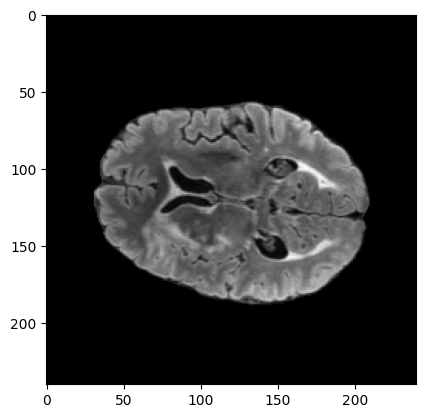

In [16]:
middle_slice = img_data[:, :, 155 // 2]
middle_slice

plt.imshow(middle_slice, cmap="gray")

IndexError: index 5 is out of bounds for axis 0 with size 5

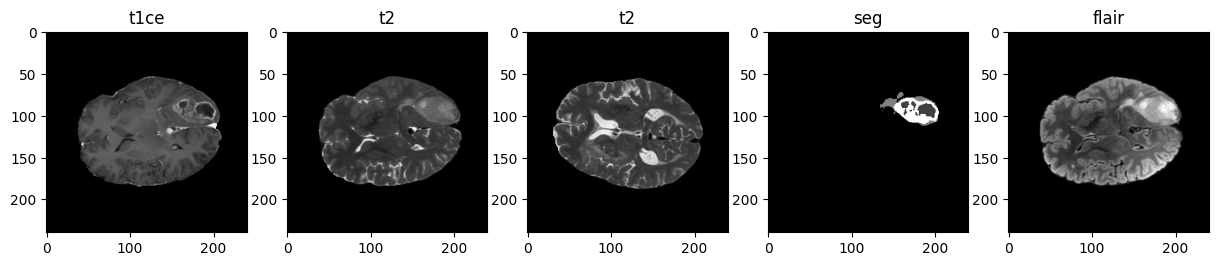

In [74]:
def get_middle_slice(img_data):
    return img_data[:, :, 155 // 2]
    
root_path = "/kaggle/working/"
img_list = []
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(15, 15))
# print(axs)
for file in os.listdir(root_path):
    if file.endswith(".nii.gz"):
        # print(file)
        img_list.append(file)
        
for idx, file in enumerate(img_list):
    full_path = os.path.join(root_path, file)
    data = nib.load(full_path)
    img_data = data.get_fdata()
    middle_slice = get_middle_slice(img_data)
    # print(middle_slice.shape)
    axs[idx].imshow(middle_slice, cmap="gray")
    axs[idx].set_title(file[16:-7])
    # print(img_data.shape)

plt.show()

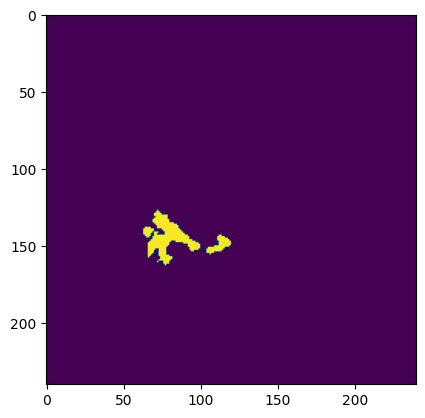

In [69]:
data = nib.load('/kaggle/working/BraTS2021_00621_seg.nii.gz')
mask_data = data.get_fdata()
mask_data.shape
plt.imshow(get_middle_slice(mask_data))